# **Energy consumption Prediction Using - XGboost Time series analysis**

### Importing Important Dependencies 

In [187]:
# Essential Libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

col_pal = sns.color_palette()

# Model Importing 
from sklearn.metrics import mean_squared_error
import xgboost as xgb
plt.style.use('fivethirtyeight')



## Data collection

In [188]:
df = pd.read_csv(r'D:\Robotics\Machine Learning Projects\XGboost Based Energy Consumption prediction\data\PJME_hourly.csv')
df=df.set_index('Datetime')



In [189]:
pd.to_datetime(df.index)

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

In [190]:
df.index = pd.to_datetime(df.index)

In [191]:
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [192]:
df.tail()

,PJME_MW
Datetime,
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0
2018-01-01 23:00:00,40164.0
2018-01-02 00:00:00,38608.0


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


In [194]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [195]:
df.isnull().sum()

PJME_MW    0
dtype: int64

From Above we can see there is no missing values in this dataset so the cleaning process is reduced

## Data Visualization

<Axes: title={'center': 'Energy Consumption in MW'}, xlabel='Datetime'>

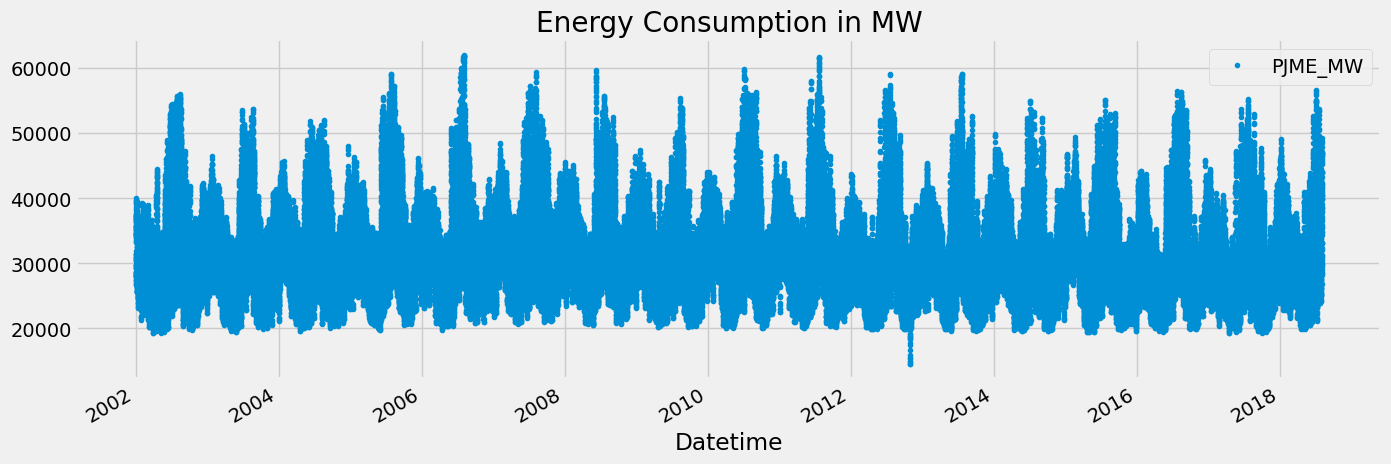

In [196]:
df.plot(style='.',
        figsize=(15,5),
        color = col_pal[0],
        title='Energy Consumption in MW')

## Train / Test Split

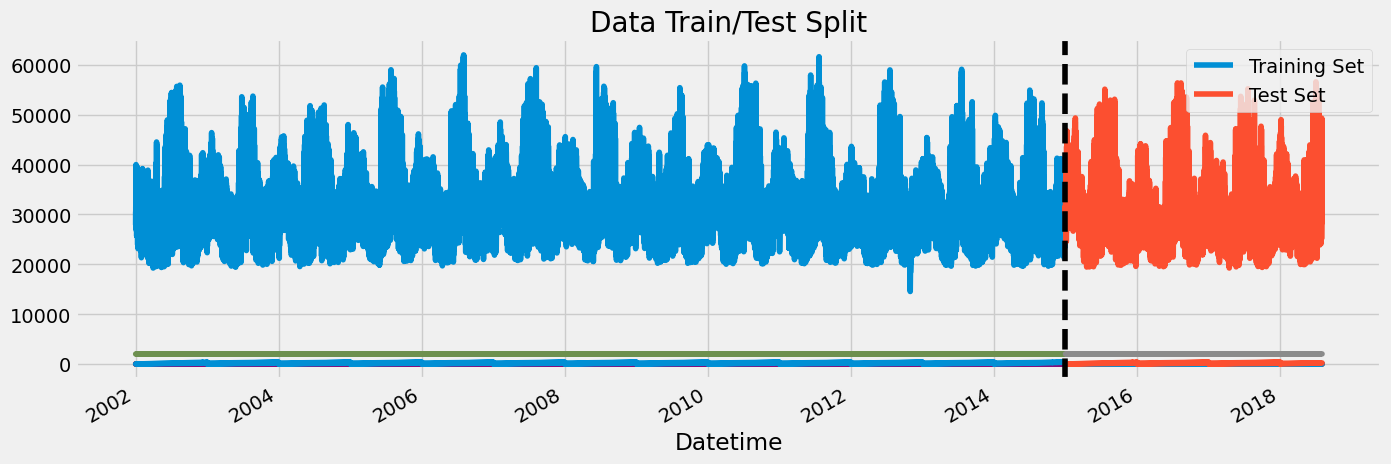

In [215]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index > '01-01-2015']
fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show() 

In [216]:
train.tail()

,PJME_MW,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,,
2014-01-01 20:00:00,36193.0,20,2,2014,1,1,1
2014-01-01 21:00:00,35601.0,21,2,2014,1,1,1
2014-01-01 22:00:00,34242.0,22,2,2014,1,1,1
2014-01-01 23:00:00,32215.0,23,2,2014,1,1,1
2014-01-02 00:00:00,30159.0,0,3,2014,1,1,2


In [217]:
test.head()

,PJME_MW,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,,
2015-12-31 01:00:00,24305.0,1,3,2015,12,4,365
2015-12-31 02:00:00,23156.0,2,3,2015,12,4,365
2015-12-31 03:00:00,22514.0,3,3,2015,12,4,365
2015-12-31 04:00:00,22330.0,4,3,2015,12,4,365
2015-12-31 05:00:00,22773.0,5,3,2015,12,4,365


In [218]:
test.tail()

,PJME_MW,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,,
2018-01-01 20:00:00,44284.0,20,0,2018,1,1,1
2018-01-01 21:00:00,43751.0,21,0,2018,1,1,1
2018-01-01 22:00:00,42402.0,22,0,2018,1,1,1
2018-01-01 23:00:00,40164.0,23,0,2018,1,1,1
2018-01-02 00:00:00,38608.0,0,1,2018,1,1,2


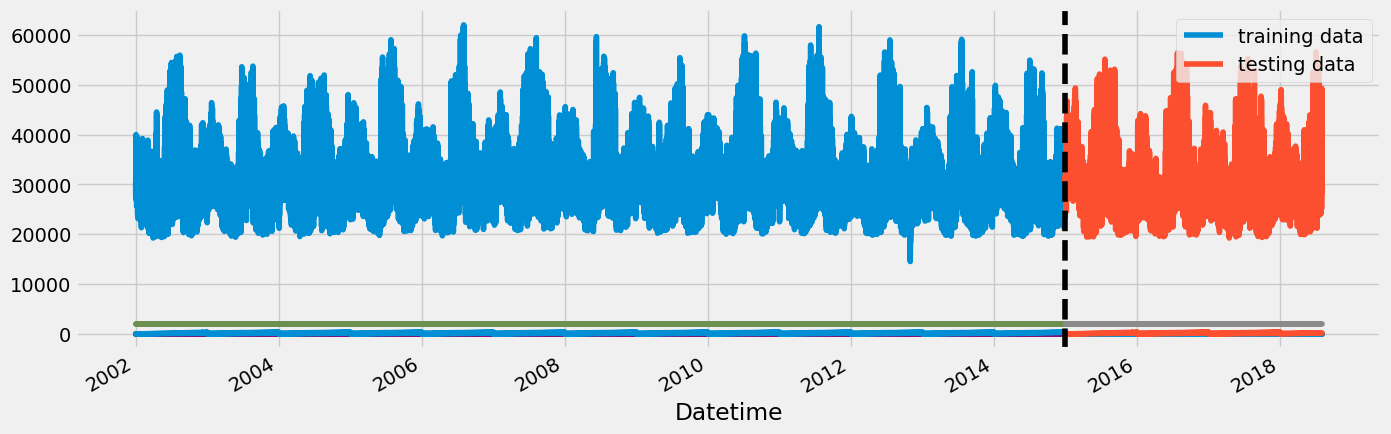

In [219]:
fig , ax = plt.subplots(figsize = (15,5))
train.plot(ax = ax,label ='Training set')
test.plot(ax =ax ,label ='Test set')
ax.axvline('01-01-2015',color = 'black',ls = '--')
ax.legend(['training data','testing data'])
plt.show()

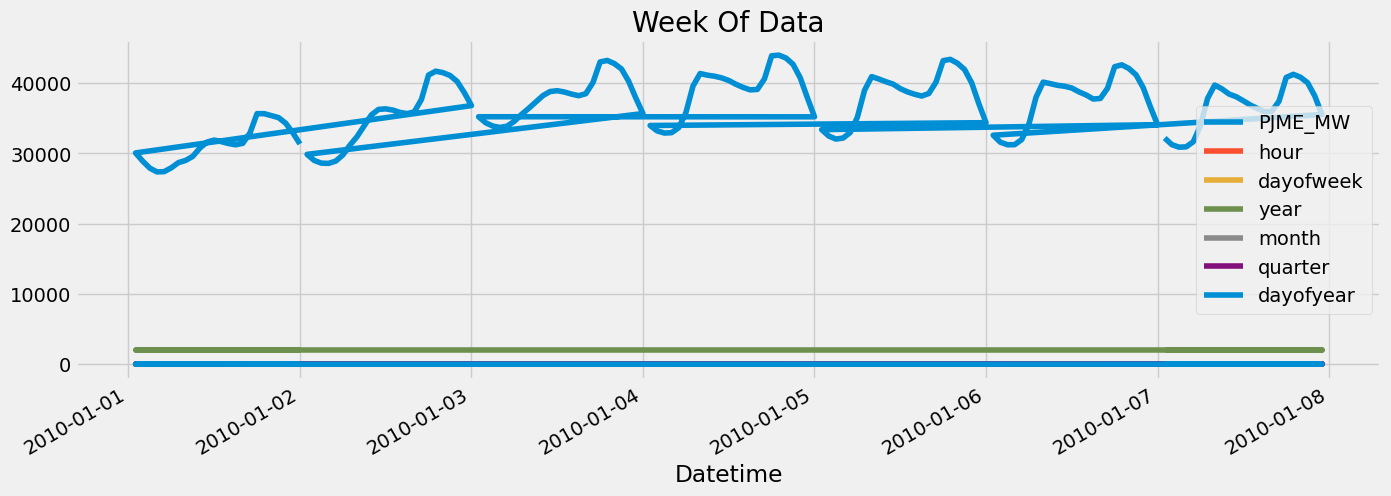

In [220]:
# Plotting data of the week 

df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()


## Feature Creation

In [221]:
df

,PJME_MW,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,2002,12,4,365
2002-12-31 02:00:00,25147.0,2,1,2002,12,4,365
2002-12-31 03:00:00,24574.0,3,1,2002,12,4,365
2002-12-31 04:00:00,24393.0,4,1,2002,12,4,365
2002-12-31 05:00:00,24860.0,5,1,2002,12,4,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,2018,1,1,1
2018-01-01 21:00:00,43751.0,21,0,2018,1,1,1
2018-01-01 22:00:00,42402.0,22,0,2018,1,1,1


In [222]:
# Function to create features 

def feature_creation(df):

    """
    Create time series features based on time series index.
    """

    df['hour']= df.index.hour
    df['dayofweek']=df.index.dayofweek
    df['year']=df.index.year
    df['month']=df.index.month
    df['quarter']=df.index.quarter
    df['dayofyear']=df.index.dayofyear
    return df

In [205]:
df = feature_creation(df)

In [223]:
df

,PJME_MW,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,2002,12,4,365
2002-12-31 02:00:00,25147.0,2,1,2002,12,4,365
2002-12-31 03:00:00,24574.0,3,1,2002,12,4,365
2002-12-31 04:00:00,24393.0,4,1,2002,12,4,365
2002-12-31 05:00:00,24860.0,5,1,2002,12,4,365
...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,2018,1,1,1
2018-01-01 21:00:00,43751.0,21,0,2018,1,1,1
2018-01-01 22:00:00,42402.0,22,0,2018,1,1,1


## Visualize feature and target relationship 

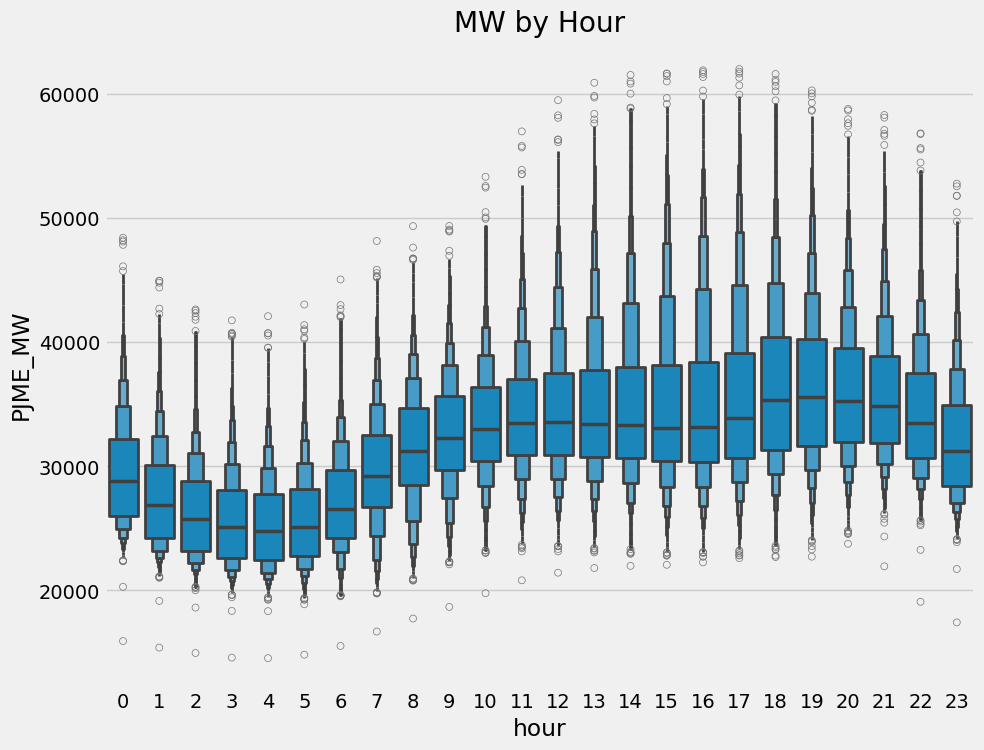

In [224]:
fig,ax = plt.subplots(figsize = (10,8))
sns.boxenplot(data=df ,x='hour',y='PJME_MW',)
ax.set_title('MW by Hour')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17780\2148177396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x = 'month',y = 'PJME_MW',palette='Blues')


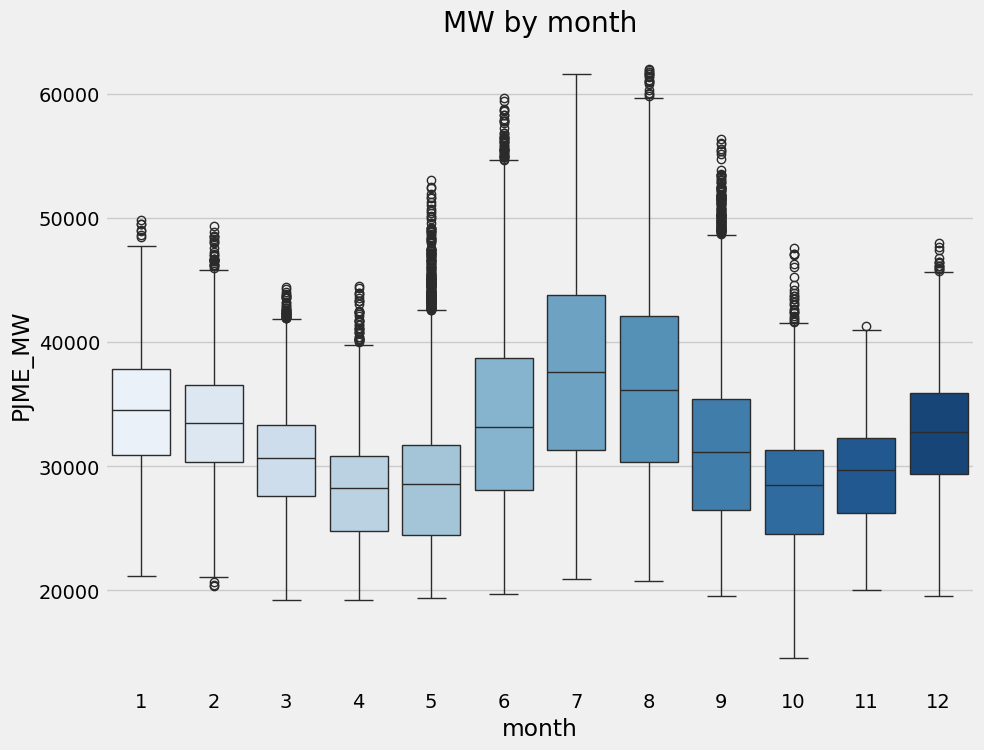

In [225]:
# Comparison with month 

fig,ax = plt.subplots(figsize = (10,8),)
sns.boxplot(data=df, x = 'month',y = 'PJME_MW',palette='Blues')
ax.set_title('MW by month')
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17780\3733269792.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df , x='year',y='PJME_MW',palette='Greens')


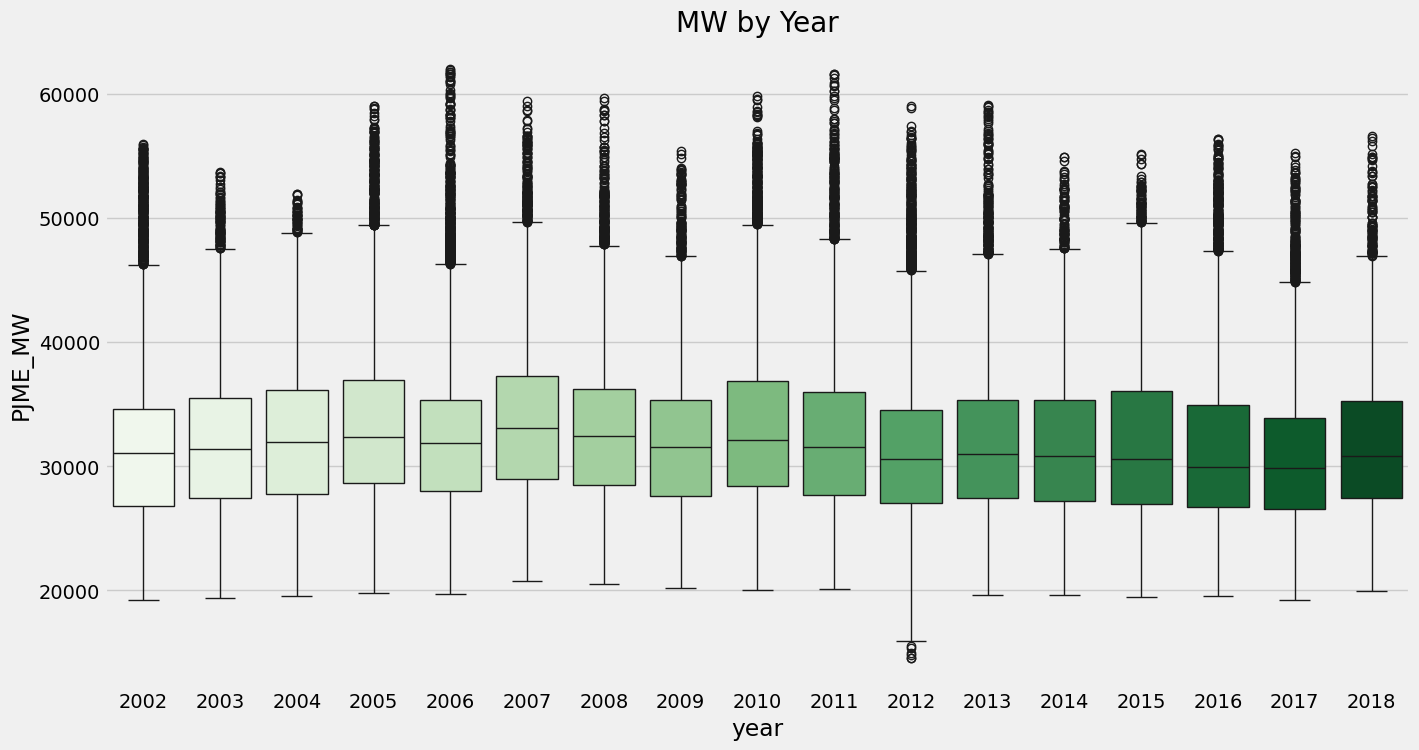

In [226]:
fig,ax = plt.subplots(figsize = (15,8))
sns.boxplot(data=df , x='year',y='PJME_MW',palette='Greens')
ax.set_title('MW by Year')
plt.show()

### Giving data for training and testing

In [227]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'year', 'month', 'quarter',
       'dayofyear'],
      dtype='object')

In [228]:
features = ['hour', 'dayofweek', 'year', 'month', 'quarter',
       'dayofyear']

In [229]:
label = 'PJME_MW'

In [230]:
# Splittling the data to features and labels 

x_train = train[features]
y_train = train[label]

In [231]:
# For testing splitting the data with features and labels

x_test = test[features]
y_test = test[label]

In [232]:
x_train.head()

,hour,dayofweek,year,month,quarter,dayofyear
Datetime,,,,,,
2002-12-31 01:00:00,1,1,2002,12,4,365
2002-12-31 02:00:00,2,1,2002,12,4,365
2002-12-31 03:00:00,3,1,2002,12,4,365
2002-12-31 04:00:00,4,1,2002,12,4,365
2002-12-31 05:00:00,5,1,2002,12,4,365


In [233]:
y_train.head()

Datetime
2002-12-31 01:00:00    26498.0
2002-12-31 02:00:00    25147.0
2002-12-31 03:00:00    24574.0
2002-12-31 04:00:00    24393.0
2002-12-31 05:00:00    24860.0
Name: PJME_MW, dtype: float64

## create the model

In [234]:
reg = xgb.XGBRegressor(n_estimators = 1000 , early_stopping_rounds = 50,
                       learning_rate = 0.01) 
reg.fit(x_train,y_train ,
        eval_set = [(x_train , y_train) ,(x_test,y_test)],
        verbose = 100)



[0]	validation_0-rmse:6407.35736	validation_1-rmse:6479.91863
[100]	validation_0-rmse:3911.97994	validation_1-rmse:4312.09901
[200]	validation_0-rmse:3244.38509	validation_1-rmse:3864.62326
[300]	validation_0-rmse:2996.08999	validation_1-rmse:3748.82401
[400]	validation_0-rmse:2830.28024	validation_1-rmse:3744.99223
[417]	validation_0-rmse:2801.66222	validation_1-rmse:3749.31981


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Feature Importance 

In [235]:
fi = pd.DataFrame(data = reg.feature_importances_,
                  index=reg.feature_names_in_,
                  columns=['importance']
                  )

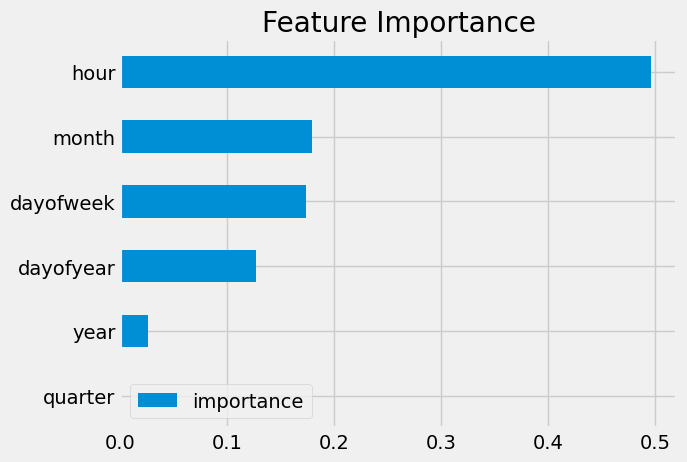

In [236]:
fi.sort_values('importance').plot(kind ='barh',title='Feature Importance')
plt.show()

# Forcast on Test

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20696\2482467138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction']=reg.predict(x_test)


,PJME_MW_x,hour_x,dayofweek_x,year_x,month_x,quarter_x,dayofyear_x,PJME_MW_y,hour_y,dayofweek_y,year_y,month_y,quarter_y,dayofyear_y,prediction
Datetime,,,,,,,,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,2002,12,4,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-31 02:00:00,25147.0,2,1,2002,12,4,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-31 03:00:00,24574.0,3,1,2002,12,4,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-31 04:00:00,24393.0,4,1,2002,12,4,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-31 05:00:00,24860.0,5,1,2002,12,4,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,2018,1,1,1,44284.0,20.0,0.0,2018.0,1.0,1.0,1.0,38623.246094
2018-01-01 21:00:00,43751.0,21,0,2018,1,1,1,43751.0,21.0,0.0,2018.0,1.0,1.0,1.0,38495.484375
2018-01-01 22:00:00,42402.0,22,0,2018,1,1,1,42402.0,22.0,0.0,2018.0,1.0,1.0,1.0,36229.527344


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17780\3617105469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(x_test)


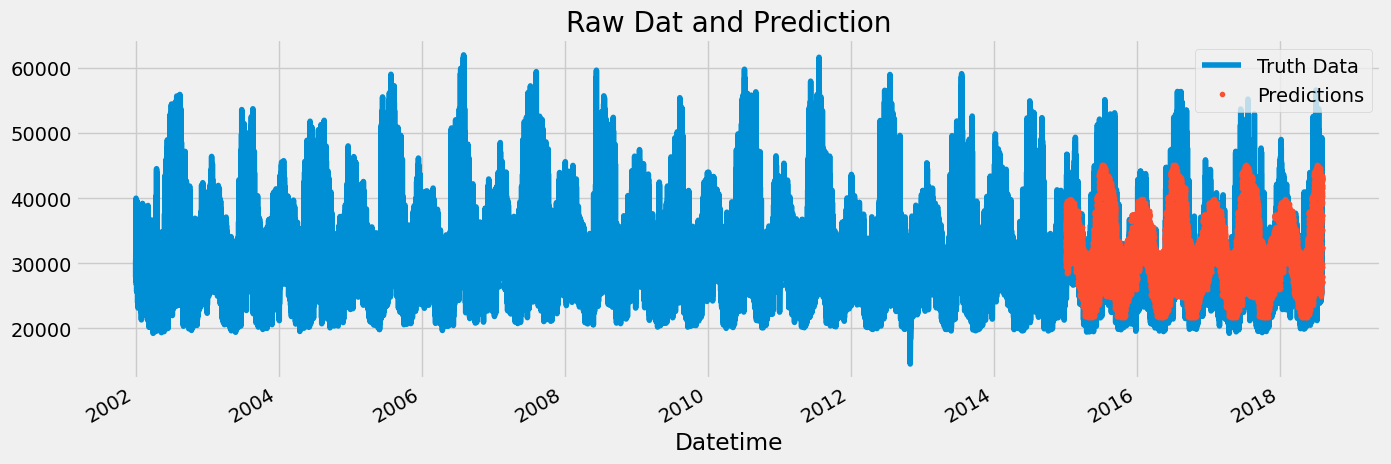

In [237]:
test['prediction'] = reg.predict(x_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

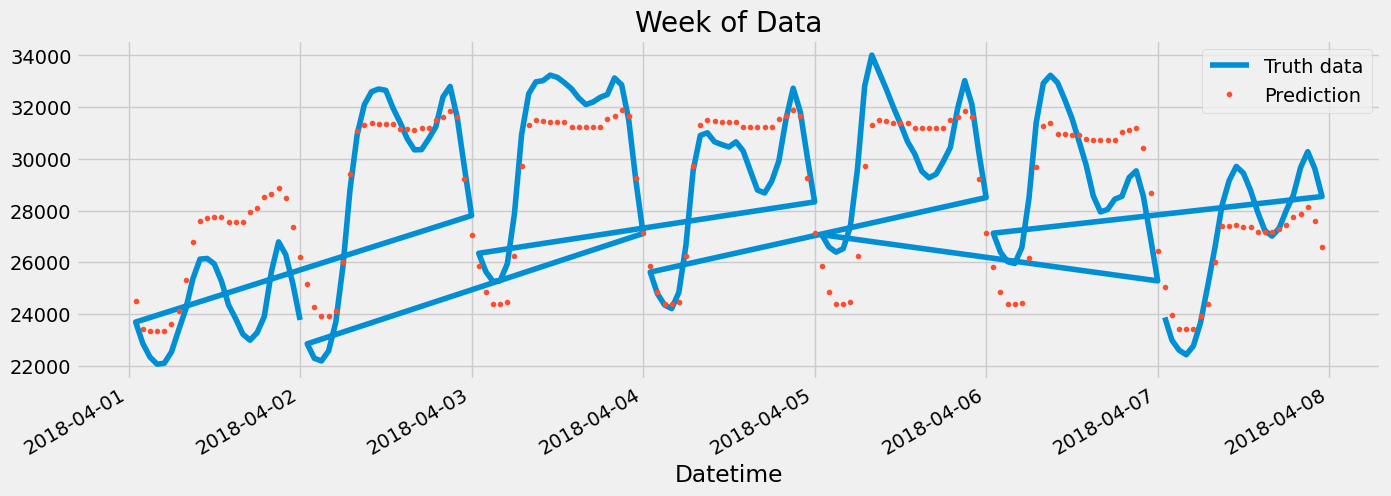

In [238]:
ax = df.loc[(df.index > '04-01-2018')& (df.index < '04-08-2018')]['PJME_MW'].plot(figsize=(15,5) , title='Week of Data')

df.loc[(df.index > '04-01-2018' ) & (df.index < '04-08-2018')]['prediction'].plot(style='.')
plt.legend(['Truth data','Prediction']
           )
plt.show()

## calculate the Error

- Look at the worst and best predicted days 


In [239]:
score = np.sqrt(mean_squared_error(test['PJME_MW'],
                                   test['prediction']))

print(f'RMSE Score on Test set : {score : 0.2f}')

RMSE Score on Test set :  3741.09


In [240]:
test['error'] = np.abs(test[label] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17780\2385077137.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = np.abs(test[label] - test['prediction'])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_17780\2385077137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['date'] = test.index.date


date
2016-08-13    13829.866211
2016-08-14    13577.304362
2016-09-10    11235.855143
2016-09-09    11032.220215
2016-08-12    10667.820312
2018-01-06    10407.698161
2015-02-20    10143.611491
2017-05-19     9495.122640
2016-07-04     9440.610596
2016-07-23     9362.332682
Name: error, dtype: float64

# Exporting the model to use outside 

In [242]:
import joblib

# save the model 
joblib.dump(reg,'energy_consumption_v0.pkl')
print('Model saved as : ')

# save the feature names 
import json

with open('features.json','w') as f:
    
    json.dump(features,f)

print("Features saved to 'Features.json")    


Model saved as : 
Features saved to 'Features.json
